In [1]:
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned_chi2_only.csv")
y = df["residuals"]

In [4]:
all_features = [
    "ZTF_x1",
    "ZTF_c",
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z"
]

short_names = {
    "ZTF_x1": "x₁",
    "ZTF_c": "c",
    "DESI_FASTSPEC_LOGMSTAR": "logM★",
    "DESI_FASTSPEC_SFR": "SFR",
    "DESI_FASTSPEC_VDISP": "σ_v",
    "DESI_FASTSPEC_DN4000": "Dn4000",
    "DESI_FASTSPEC_g_minus_r": "g−r",
    "DESI_FASTSPEC_AGE": "Age",
    "DESI_METADATA_Z": "z"
}

best_params = {'n_estimators': 600, 'max_depth': 26, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True, 'max_samples': 0.5041681530892771}


X = df[all_features]
rf = RandomForestRegressor(**best_params)
rf.fit(X, y)

importances = pd.Series(
    rf.feature_importances_,
    index=[short_names[f] for f in all_features]
).sort_values(ascending=False)

print("Feature Importances (MDI):")
print(importances)

Feature Importances (MDI):
c         0.196661
g−r       0.149730
z         0.141792
x₁        0.109856
Dn4000    0.105056
logM★     0.102838
σ_v       0.070721
Age       0.063015
SFR       0.060331
dtype: float64


Baseline RMS (no ML): 0.1867


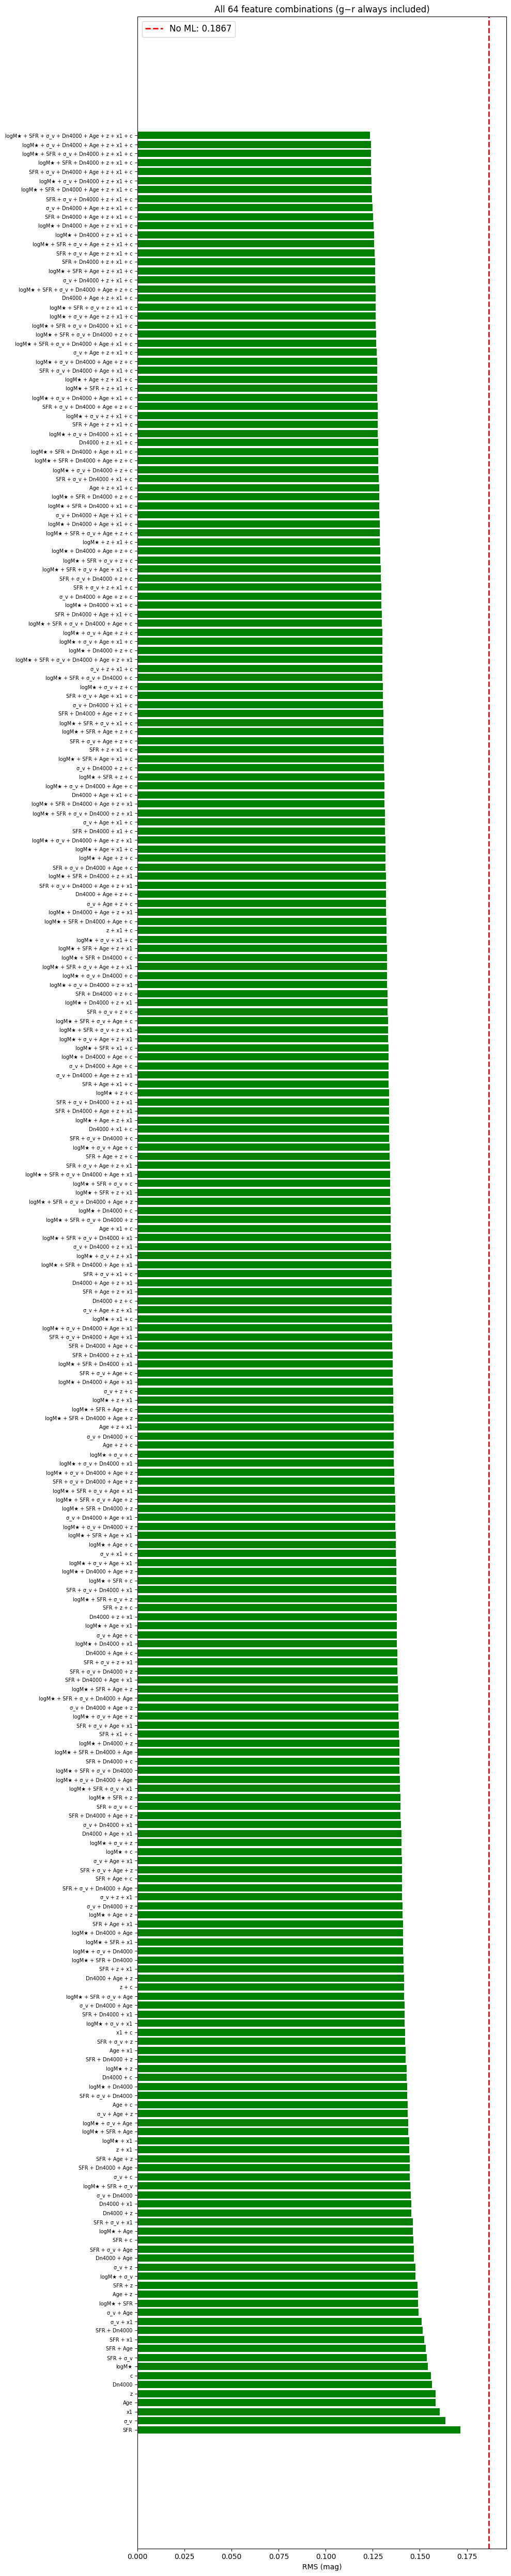

In [6]:
# Baseline: RMS with no ML correction
rms_baseline = np.sqrt(np.mean(df["residuals"] ** 2))
print(f"Baseline RMS (no ML): {rms_baseline:.4f}")

best_params = {'n_estimators': 600, 'max_depth': 26, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True, 'max_samples': 0.5041681530892771}


# g-r always included
fixed_feature = None

# These get varied
optional_features = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z",
    "ZTF_x1",
    "ZTF_c"
]

short_names = {
    "DESI_FASTSPEC_LOGMSTAR": "logM★",
    "DESI_FASTSPEC_SFR": "SFR",
    "DESI_FASTSPEC_VDISP": "σ_v",
    "DESI_FASTSPEC_DN4000": "Dn4000",
    "DESI_FASTSPEC_g_minus_r": "g−r",
    "DESI_FASTSPEC_AGE": "Age",
    "DESI_METADATA_Z": "z",
    "ZTF_x1": "x1",
    "ZTF_c": "c"
}

results = []

# g-r alone, then g-r + every combo of 1–6 optional features
for n_opt in range(0, len(optional_features) + 1):
    for combo in combinations(optional_features, n_opt):
        combo_list = ([fixed_feature] if fixed_feature else []) + list(combo)
        if not combo_list:
            continue  # skip empty feature set

        params = best_params.copy()
        if params["max_features"] is None and len(combo_list) < 3:
            params["max_features"] = len(combo_list)

        X_combo = df[combo_list]
        rf = RandomForestRegressor(**params)
        rf.fit(X_combo, y)
        y_pred_combo = rf.predict(X_combo)

        corrected_residuals = df["residuals"] - y_pred_combo
        rms = np.sqrt(np.mean(corrected_residuals ** 2))

        label = " + ".join([short_names[f] for f in combo_list])
        results.append({"features": label, "n_features": len(combo_list), "rms": rms})

# Sort by RMS (best at top)
results_df = pd.DataFrame(results).sort_values("rms", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 50))  # taller figure

colors = ["green" if r < rms_baseline else "gray" for r in results_df["rms"]]
ax.barh(range(len(results_df)), results_df["rms"], color=colors)
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df["features"], fontsize=7)
ax.axvline(rms_baseline, color="red", linestyle="--", linewidth=2, label=f"No ML: {rms_baseline:.4f}")
ax.set_xlabel("RMS (mag)")
ax.set_title("All 64 feature combinations (g−r always included)")
ax.legend(fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Playground And Hacky Code #

In [2]:
import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned_chi2_only.csv")
y = df["residuals"]

feature_cols = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z"
]

X = df[feature_cols]
X_np = X.to_numpy()
y_np = y.to_numpy()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 3000, step=50),
        "max_depth": trial.suggest_int("max_depth", 1, 100),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "n_jobs": -1,
        "random_state": 42,
    }
    if params["bootstrap"]:
        params["max_samples"] = trial.suggest_float("max_samples", 0.1, 1.0)

    rf = RandomForestRegressor(**params)
    fold_scores = []
    for train_idx, val_idx in kf.split(X_np):
        rf.fit(X_np[train_idx], y_np[train_idx])
        pred = rf.predict(X_np[val_idx])
        fold_scores.append(mean_squared_error(y_np[val_idx], pred))
    return np.mean(fold_scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=150, show_progress_bar=True)

print("Best CV MSE:", study.best_value)
print("Best hyperparameters:")
print(study.best_params)

# Fit on full dataset with best params and show feature importances
best_params = study.best_params.copy()
best_params["n_jobs"] = -1
best_params["random_state"] = 42

rf = RandomForestRegressor(**best_params)
rf.fit(X, y)

print("\nFeature Importances (MDI):")
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

  0%|          | 0/150 [00:00<?, ?it/s]

Best CV MSE: 0.03155837089236488
Best hyperparameters:
{'n_estimators': 350, 'max_depth': 68, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': True, 'max_samples': 0.1505640672337139}

Feature Importances (MDI):
DESI_FASTSPEC_g_minus_r    0.232407
DESI_FASTSPEC_LOGMSTAR     0.180553
DESI_METADATA_Z            0.171678
DESI_FASTSPEC_DN4000       0.170336
DESI_FASTSPEC_AGE          0.102613
DESI_FASTSPEC_SFR          0.086306
DESI_FASTSPEC_VDISP        0.056107
dtype: float64


/var/folders/71/hv72gkrs7g59ty6664549kjr0000gr/T/ipykernel_22152/2940220685.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_optimization_history(study)


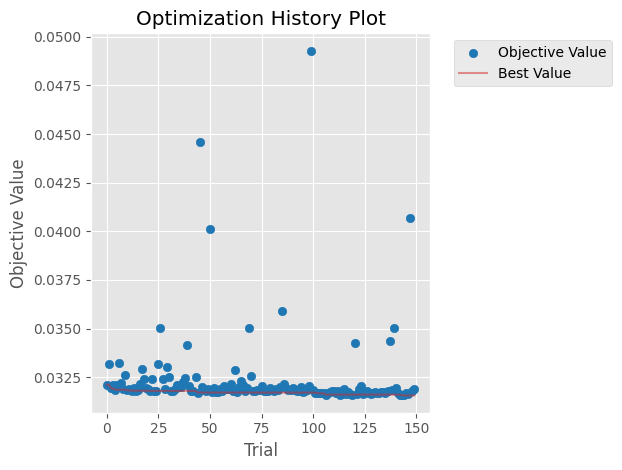

In [3]:
import optuna.visualization.matplotlib as vis

vis.plot_optimization_history(study)
plt.tight_layout()
plt.show()


In [5]:
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict

df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned_chi2_only.csv")
y = df["residuals"]

rms_baseline = np.sqrt(np.mean(df["residuals"] ** 2))
print(f"Baseline RMS (no ML): {rms_baseline:.4f}")

best_params = {
    'n_estimators': 2700,
    'max_depth': 44,
    'min_samples_split': 15,
    'min_samples_leaf': 8,
    'max_features': None,
    'bootstrap': True,
    'max_samples': 0.10209831112603257,
    'n_jobs': -1,
    'random_state': 42,
}

fixed_feature = "DESI_FASTSPEC_g_minus_r"

optional_features = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z",
    "ZTF_c",
    "ZTF_x1"
]

short_names = {
    "DESI_FASTSPEC_LOGMSTAR": "logM★",
    "DESI_FASTSPEC_SFR": "SFR",
    "DESI_FASTSPEC_VDISP": "σ_v",
    "DESI_FASTSPEC_DN4000": "Dn4000",
    "DESI_FASTSPEC_g_minus_r": "g−r",
    "DESI_FASTSPEC_AGE": "Age",
    "DESI_METADATA_Z": "z"
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for n_opt in range(0, len(optional_features) + 1):
    for combo in combinations(optional_features, n_opt):
        combo_list = [fixed_feature] + list(combo)
        label = " + ".join([short_names[f] for f in combo_list])

        params = best_params.copy()
        if params["max_features"] is None and len(combo_list) < 3:
            params["max_features"] = len(combo_list)

        X_combo = df[combo_list]

        rf = RandomForestRegressor(**params)

        # Out-of-fold predictions (honest)
        y_pred_cv = cross_val_predict(rf, X_combo, y, cv=kf)
        rms_cv = np.sqrt(np.mean((y.to_numpy() - y_pred_cv) ** 2))

        # Training predictions (optimistic, for comparison)
        rf.fit(X_combo, y)
        y_pred_train = rf.predict(X_combo)
        rms_train = np.sqrt(np.mean((y.to_numpy() - y_pred_train) ** 2))

        results.append({
            "features": label,
            "n_features": len(combo_list),
            "rms_cv": rms_cv,
            "rms_train": rms_train
        })

        print(f"{label:60s} | CV: {rms_cv:.4f} | Train: {rms_train:.4f}")

results_df = pd.DataFrame(results).sort_values("rms_cv", ascending=True).reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 50))  # taller figure

y_pos = range(len(results_df))
ax.barh(y_pos, results_df["rms_train"], color="lightblue", alpha=0.6, label="Training RMS (optimistic)")
ax.barh(y_pos, results_df["rms_cv"], color="steelblue", alpha=0.9, label="Out-of-fold RMS (honest)")
ax.set_yticks(y_pos)
ax.set_yticklabels(results_df["features"], fontsize=7)
ax.axvline(rms_baseline, color="red", linestyle="--", linewidth=2, label=f"No ML: {rms_baseline:.4f}")
ax.set_xlabel("RMS (mag)")
ax.set_title("All 64 feature combinations (g−r always included)")
ax.legend(fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

Baseline RMS (no ML): 0.1867
g−r                                                          | CV: 0.1796 | Train: 0.1770
g−r + logM★                                                  | CV: 0.1789 | Train: 0.1756
g−r + SFR                                                    | CV: 0.1796 | Train: 0.1763
g−r + σ_v                                                    | CV: 0.1797 | Train: 0.1762
g−r + Dn4000                                                 | CV: 0.1796 | Train: 0.1755
g−r + Age                                                    | CV: 0.1800 | Train: 0.1765
g−r + z                                                      | CV: 0.1783 | Train: 0.1738


KeyError: 'ZTF_c'